# Classification of Blogs

In [4]:
!pip install mlflow

     |████████████████████████████████| 24.7 MB 750 kB/s eta 0:00:01     |██████████████                  | 10.8 MB 472 kB/s eta 0:00:30
     |████████████████████████████████| 247 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 85 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 854 kB/s eta 0:00:01
     |████████████████████████████████| 147 kB 990 kB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 667 kB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 1.5 MB/s eta 0:00:01
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
     |████████████████████████████████| 30.8 MB 883 kB/s eta 0:00:01
     |████████████████████████████████| 114 kB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 46 kB 8.6 MB/s  eta 0:00:01
  Using cached cachetools-6.2.6-py3-none-any.whl (11 kB)
  Using cached packaging-25.0-py3-none-any.whl (66 kB)
     |████████████████████████████████| 838 kB 5.7 MB/s eta 0:00:01
 

In [5]:
!pip install pyngrok

You should consider upgrading via the '/Users/adithyan/Desktop/Blogengine/venv/bin/python3 -m pip install --upgrade pip' command.


In [6]:
!pip install seaborn 
!pip install nltk

     |████████████████████████████████| 294 kB 951 kB/s eta 0:00:01
You should consider upgrading via the '/Users/adithyan/Desktop/Blogengine/venv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/adithyan/Desktop/Blogengine/venv/bin/python3 -m pip install --upgrade pip' command.


In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression

import mlflow
import mlflow.sklearn

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adithyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/Users/adithyan/Desktop/Blogengine/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [8]:
train_df=pd.read_csv("./dataset/test.csv",header=0,names=['classid','title','desc'])
test_df=pd.read_csv("dataset/test.csv",header=0,names=['classid','title','desc'])


In [9]:
train_df.head()

,classid,title,desc
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [10]:
test_df.head()

,classid,title,desc
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [11]:
train_df['text'] = train_df['title'] + " " + train_df['desc']
test_df['text'] = test_df['title'] + " " + test_df['desc']

In [12]:
train_x = train_df['text']
train_y = train_df['classid']

test_x = test_df['text']
test_y = test_df['classid']

In [13]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()

    # remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
train_x = train_x.apply(preprocess)
test_x = test_x.apply(preprocess)

print(train_x.head())  # MUST look like normal words

0    fears n pension talks unions representing work...
1    race second private team sets launch date huma...
2    ky company wins grant study peptides ap ap com...
3    prediction unit helps forecast wildfires ap ap...
4    calif aims limit farmrelated smog ap ap southe...
Name: text, dtype: object


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)  # limit features (better performance)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

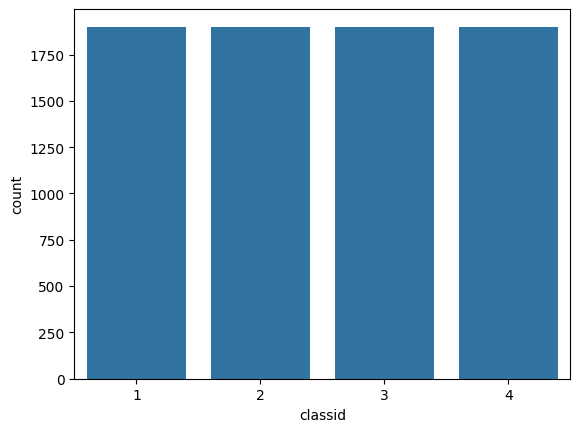

In [16]:
sns.countplot(x=train_y)
plt.show()

In [17]:
tfidf = TfidfVectorizer(min_df=3)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

print("Features:", len(tfidf.get_feature_names_out()))

Features: 8556


In [18]:
import mlflow
import mlflow.sklearn

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC

# -------------------------------
# MLflow Setup
# -------------------------------
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("News Classification Advanced")

# -------------------------------
# Tuned Models
# -------------------------------
models = {
    "Naive_Bayes": MultinomialNB(alpha=0.5),
    "SGD": SGDClassifier(alpha=0.0001, max_iter=1000),
    "Logistic_Regression": LogisticRegression(max_iter=1000, C=1.0),
    "SVM": LinearSVC(C=1.0)
}

best_model = None
best_score = 0
best_name = ""

# -------------------------------
# Training Loop
# -------------------------------
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Train
        model.fit(train_vec, train_y)

        # Predict
        pred = model.predict(test_vec)

        # Metrics
        acc = accuracy_score(test_y, pred)
        precision = precision_score(test_y, pred, average='weighted')
        recall = recall_score(test_y, pred, average='weighted')
        f1 = f1_score(test_y, pred, average='weighted')

        # Log params
        mlflow.log_param("model", name)

        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        # Log model
        mlflow.sklearn.log_model(model, name="model")

        print(f"{name} → Accuracy: {acc:.4f}")

        # Track best model
        if acc > best_score:
            best_score = acc
            best_model = model
            best_name = name

# -------------------------------
# Log Best Model Separately
# -------------------------------
with mlflow.start_run(run_name="BEST_MODEL"):

    mlflow.log_param("best_model", best_name)
    mlflow.log_metric("best_accuracy", best_score)

    mlflow.sklearn.log_model(best_model, name="best_model")

print("\n🔥 BEST MODEL:", best_name)
print("🔥 BEST ACCURACY:", best_score)

2026/04/20 20:57:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Naive_Bayes → Accuracy: 0.9314


2026/04/20 20:57:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


SGD → Accuracy: 0.9676


2026/04/20 20:57:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logistic_Regression → Accuracy: 0.9495


2026/04/20 20:57:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


SVM → Accuracy: 0.9892


2026/04/20 20:57:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🔥 BEST MODEL: SVM
🔥 BEST ACCURACY: 0.9892105263157894


In [20]:
!mlflow ui --host 0.0.0.0 --port 5001

/Users/adithyan/Desktop/Blogengine/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[2026-04-20 20:59:27 +0530] [15445] [INFO] Starting gunicorn 23.0.0
[2026-04-20 20:59:27 +0530] [15445] [INFO] Listening at: http://0.0.0.0:5001 (15445)
[2026-04-20 20:59:27 +0530] [15445] [INFO] Using worker: sync
[2026-04-20 20:59:27 +0530] [15446] [INFO] Booting worker with pid: 15446
[2026-04-20 20:59:28 +0530] [15447] [INFO] Booting worker with pid: 15447
[2026-04-20 20:59:28 +0530] [15448] [INFO] Booting worker with pid: 15448
[2026-04-20 20:59:28 +0530] [15449] [INFO] Booting worker with pid: 15449
/Users/adithyan/Desktop/Blogengine/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 

In [17]:
import joblib

# Save without overwriting existing files
joblib.dump(tfidf, "tfidf_saved.pkl")
joblib.dump(best_model, "best_model_saved.pkl")

print("✅ Vectorizer and Best Model saved successfully!")

✅ Vectorizer and Best Model saved successfully!
